# Faktör Pozlama Analizörü (Factor-Exposure Analyzer)
Bu notebook, belirli hisse senetlerinin piyasa faktörlerine (Market, Size, Value) olan duyarlılığını Çoklu Doğrusal Regresyon (OLS) kullanarak analiz eder.

**Analiz Kapsamı:**
- **Mkt-RF:** Piyasa Risk Primi
- **SMB (Small Minus Big):** Boyut Faktörü
- **HML (High Minus Low):** Değer Faktörü
- **Hisseler:** NVDA, ASML, AMD, TSM

### Adım 1 - Veri Seti Üretimi
Gerçekçi piyasa dinamiklerini yansıtan sentetik bir veri seti oluşturuyoruz.

In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Parametrelerin Belirlenmesi
np.random.seed(42)
n_days = 252
stocks = ['NVDA', 'ASML', 'AMD', 'TSM']
factors = ['Mkt-RF', 'SMB', 'HML']

# Tarih indeksi
end_date = datetime.now()
dates = [end_date - timedelta(days=x) for x in range(n_days)]
dates.reverse()

# Faktör Getirileri
mkt_rf = np.random.normal(0.0006, 0.015, n_days)
smb = np.random.normal(0.0001, 0.008, n_days)
hml = np.random.normal(-0.0002, 0.009, n_days)
rf = 0.0001

df_factors = pd.DataFrame({
    'Date': dates,
    'Mkt-RF': mkt_rf,
    'SMB': smb,
    'HML': hml,
    'RF': rf
})

# Hisse Betaları (Sektörel Varsayımlar)
stock_betas = {
    'NVDA': {'Mkt-RF': 1.8, 'SMB': 0.4, 'HML': -0.7},
    'ASML': {'Mkt-RF': 1.4, 'SMB': 0.2, 'HML': -0.4},
    'AMD':  {'Mkt-RF': 1.6, 'SMB': 0.5, 'HML': -0.6},
    'TSM':  {'Mkt-RF': 1.3, 'SMB': 0.1, 'HML': -0.3}
}

for stock in stocks:
    betas = stock_betas[stock]
    noise = np.random.normal(0, 0.02, n_days)
    excess_return = (
        betas['Mkt-RF'] * df_factors['Mkt-RF'] + 
        betas['SMB'] * df_factors['SMB'] + 
        betas['HML'] * df_factors['HML'] + 
        noise
    )
    df_factors[stock] = excess_return + df_factors['RF']

df_factors.to_csv('factor_exposure_data.csv', index=False)
print("Adım 1 Tamamlandı: factor_exposure_data.csv oluşturuldu.")

Adım 1 Tamamlandı: factor_exposure_data.csv oluşturuldu.


### Adım 2 - Veri İşleme
Regresyon analizi için fazla getirileri (Excess Returns) hesaplıyoruz.

In [10]:
df = pd.read_csv('factor_exposure_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Bağımlı değişken hazırlığı: R_i - RF
for stock in stocks:
    df[f'{stock}_Excess'] = df[stock] - df['RF']

print("Adım 2 Tamamlandı: Fazla getiriler hesaplandı.")

Adım 2 Tamamlandı: Fazla getiriler hesaplandı.


### Adım 3 - OLS Regresyon Motoru
`statsmodels` kullanarak her hisse için faktör duyarlılıklarını hesaplıyoruz.

In [11]:
%pip install statsmodels
import statsmodels.api as sm

results_list = []
X = df[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)  # Alpha için sabit ekle

for stock in stocks:
    y = df[f'{stock}_Excess']
    model = sm.OLS(y, X).fit()
    
    results_list.append({
        'Stock': stock,
        'Alpha (Annualized)': model.params['const'] * 252,
        'Market_Beta': model.params['Mkt-RF'],
        'Size_Beta (SMB)': model.params['SMB'],
        'Value_Beta (HML)': model.params['HML'],
        'R-Squared': model.rsquared,
        'P-Value_Avg': model.pvalues.mean()
    })

df_results = pd.DataFrame(results_list)
print("Adım 3 Tamamlandı: Regresyon modelleri eğitildi.")
df_results

Note: you may need to restart the kernel to use updated packages.
Adım 3 Tamamlandı: Regresyon modelleri eğitildi.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


,Stock,Alpha (Annualized),Market_Beta,Size_Beta (SMB),Value_Beta (HML),R-Squared,P-Value_Avg
0,NVDA,0.758666,1.809893,0.441284,-0.652085,0.671579,0.003901
1,ASML,0.499489,1.526341,0.283174,-0.238107,0.539424,0.080678
2,AMD,0.501695,1.620840,0.587502,-0.657769,0.606174,0.028424
3,TSM,0.306937,1.289310,0.183658,-0.509202,0.473166,0.147789


### Adım 4 - Görselleştirme
Sonuçları karşılaştırmalı bir grafik üzerinde inceliyoruz.

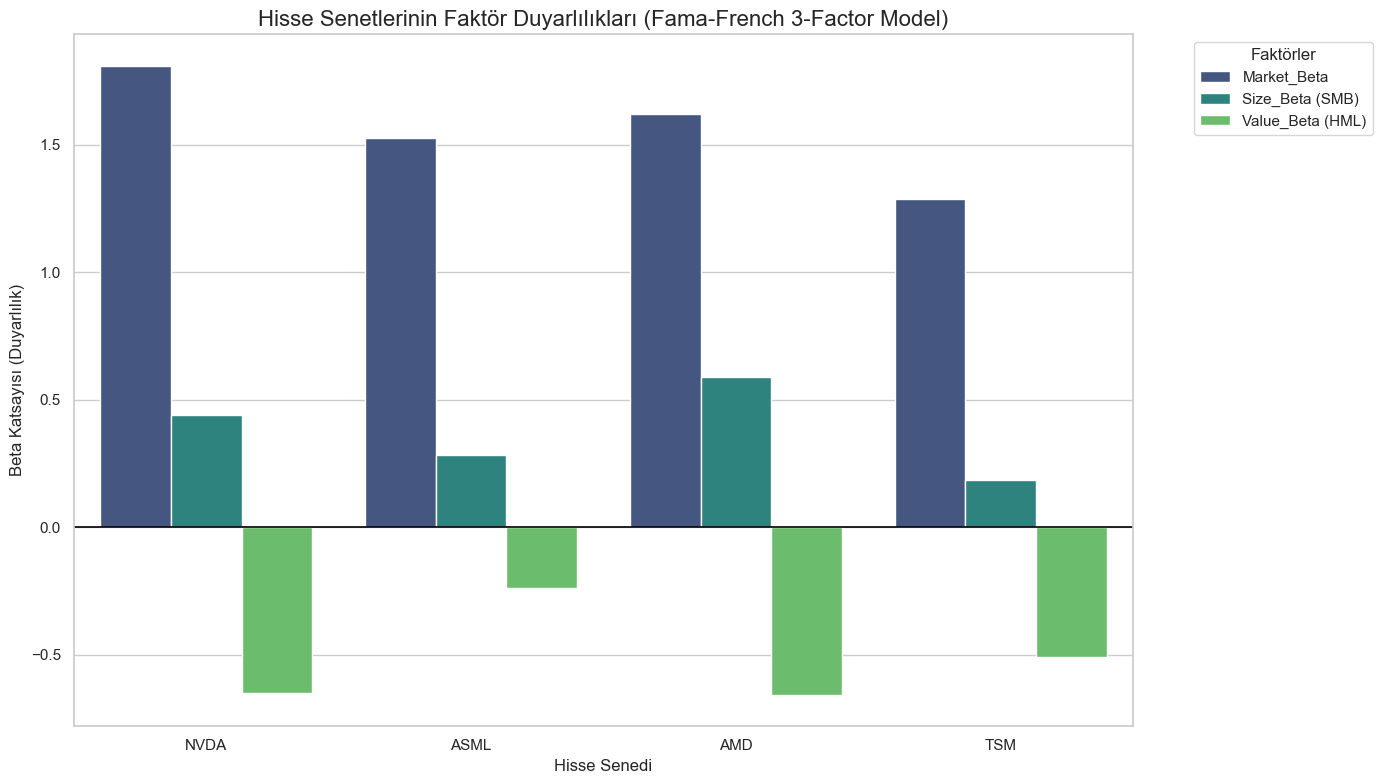

Adım 4 Tamamlandı: Analiz raporu görselleştirildi.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Veriyi görselleştirme için erit (melt)
plot_data = df_results.melt(id_vars='Stock', 
                           value_vars=['Market_Beta', 'Size_Beta (SMB)', 'Value_Beta (HML)'], 
                           var_name='Factor', value_name='Exposure')

sns.barplot(data=plot_data, x='Stock', y='Exposure', hue='Factor', palette='viridis')

plt.title('Hisse Senetlerinin Faktör Duyarlılıkları (Fama-French 3-Factor Model)', fontsize=16)
plt.ylabel('Beta Katsayısı (Duyarlılık)')
plt.xlabel('Hisse Senedi')
plt.axhline(0, color='black', linewidth=1.2)
plt.legend(title='Faktörler', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Adım 4 Tamamlandı: Analiz raporu görselleştirildi.")